## Our Framework Evaluation with Wisig Dataset

Dataset: [link](https://cores.ee.ucla.edu/downloads/datasets/wisig/)

In [1]:
%reload_ext autoreload
%autoreload 2

import os
import numpy as np
import matlab
import cfo_utils
import utils
import matplotlib.pyplot as plt
from dataset_api import DatasetAPI
from extractor_api import ExtractorAPI
from evaluation_api import EvaluationAPI
from fingerprinting_api import FingerprintingAPI
from dataset_preparation import ChannelIndSpectrogram
import random
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

os.environ['TF_DETERMINISTIC_OPS'] = '1'

# DATASET_NAME =           DatasetAPI.DATASET_WISIG_OLD
DATASET_NAME =           DatasetAPI.DATASET_WISIG_NEW
RX_NODES =               [DatasetAPI.RX_1]
ROOT_DIRECTORY =         '/home/smazokha2016/Desktop'
MATLAB_SRC_DIRECTORY =   '/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting'
MATLAB_SESSION_ID =      'fp_workflow'
AUG_ON =                 False

DATA_CONFIG = {
    'dataset_name':      DATASET_NAME,
    'frame_count_train': 1000, # 200 for v2, 500 for v4, 500 for wisig
    'frame_count_epoch': 100,
    'samples_count':     400
}

AUG_CONFIG = {
    'multiplier':        5,
    't_rms_bounds':      matlab.double([1, 2]),
    'd_f_bounds':        matlab.double([0, 1]),
    'k_factor_bounds':   matlab.double([0, 1]),
    'awgn':              matlab.double([0, 1]),
}

MODEL_CONFIG = {
    'batch_size':        32,
    'loss_type':         'triplet_loss', 'alpha': 1.0,
    # 'loss_type':         'quadruplet_loss', 'alpha': 1.2,
    'fp_len':            512,
    'row':               100,
    'enable_ind':        False
}

extractor_api = ExtractorAPI()
dataset_api = DatasetAPI(root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
fp_api = FingerprintingAPI(rx_ids = RX_NODES, data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=MODEL_CONFIG, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
eval_api = EvaluationAPI(rx_ids = RX_NODES, data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=MODEL_CONFIG, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)

2024-11-03 16:43:35.369352: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-03 16:43:35.369409: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-03 16:43:35.370145: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-03 16:43:35.374529: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-03 16:43:36.058894: W tensorflow/compiler/tf2

In [2]:
enable_training = False

if enable_training: 
    ndays = 1
    # augment_multiplier = int(2/ndays)
    augment_multiplier = 2

    # models, histories = fp_api.train_models()
    # models, histories = fp_api.train_models_wisig_old(apply_noise=False, ndays=ndays, equalized=False, compensate_cfo=False, augment=True, augment_cfo=False, augment_multiplier=augment_multiplier)
    models, histories = fp_api.train_models_wisig_new(apply_noise=False, ndays=ndays, equalized=False, compensate_cfo=False, augment=True, augment_cfo=False, augment_multiplier=augment_multiplier)

    history = histories[RX_NODES[0]]

    plt.figure(figsize=(8, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss During Training')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
else: 
    # models = fp_a pi.load_models()
    models = fp_api.load_models_wisig(is_new_dataset=True)

model = models[RX_NODES[0]]

2024-11-03 16:44:12.880316: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 861 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:03:00.0, compute capability: 8.0
2024-11-03 16:44:12.881684: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 78640 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:04:00.0, compute capability: 8.0
2024-11-03 16:44:12.882927: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 78640 MB memory:  -> device: 2, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:43:00.0, compute capability: 8.0


Enrollment devices: [269, 280, 315, 380, 391, 398]
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.


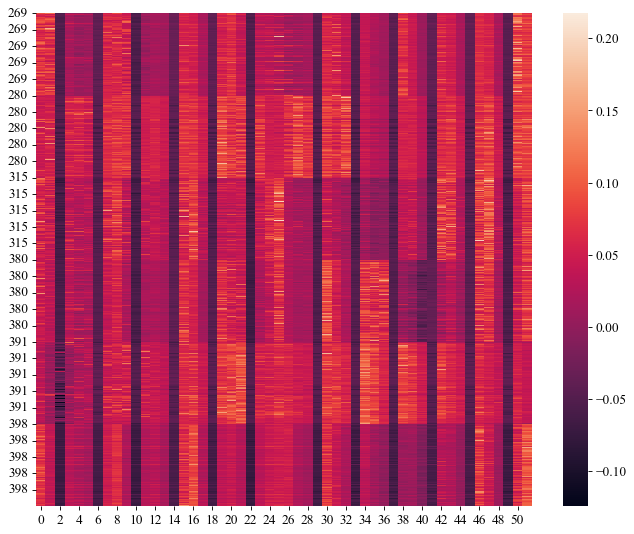

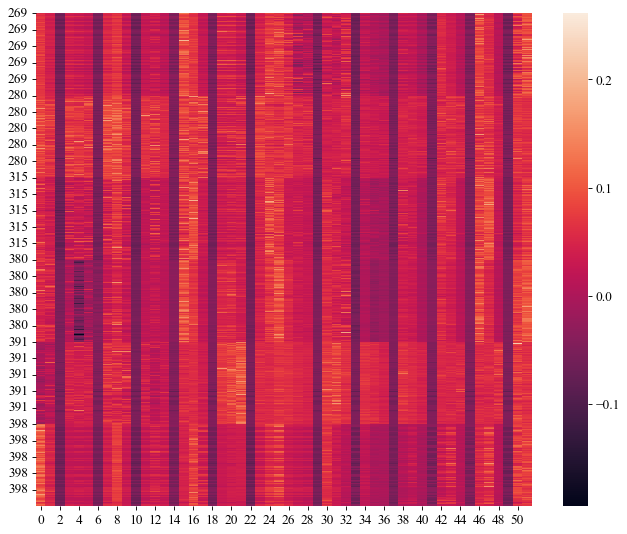

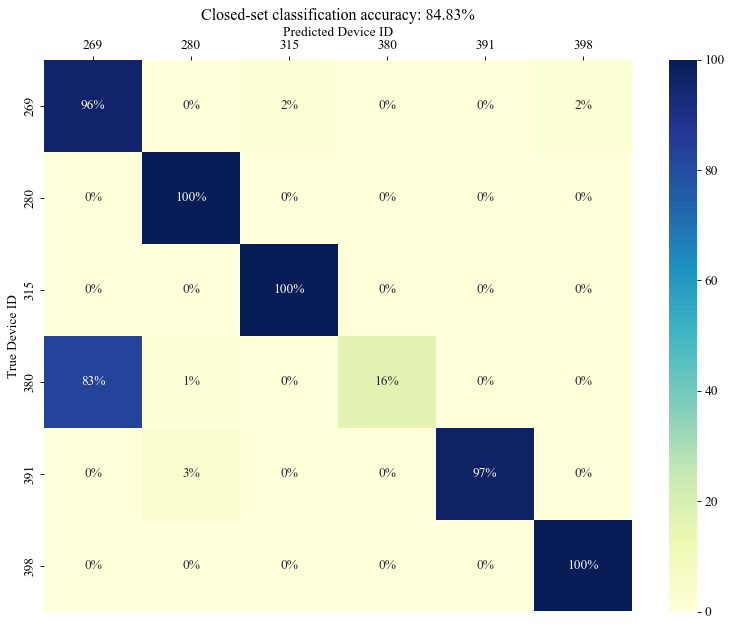

Joint Devices. Closed-set classification accuracy: 84.83%


In [11]:
# Days are 0-based
day_enroll = 0
day_identify = 3

EQUALIZED = False
# CFO_COMP_ON = False
# CFO_AUG_ON = False
RSSI_FILTERING_ON = False
CFO_FILTERING_ON = False
TEST_DISJOINT = False

def evaluate_wisig_old():
    # 1. Retrieve information about the WiSig dataset (device IDs, paths, etc)
    dataset_train_paths, dataset_epoch_paths, _, _, node_ids_epoch, _ = dataset_api.load_dataset_info(DATA_CONFIG['dataset_name'], RX_NODES[0], None, wisig_equalized=EQUALIZED, wisig_disjoint=TEST_DISJOINT)

    # Let's show devices used for enrollment / identification
    print(f'Enrollment devices: {node_ids_epoch}')

    # 2. Prepare signal & labels for enrollment subset
    data_enroll, labels_enroll, _ = dataset_api.load_raw_dataset_wisig(dataset_train_paths[day_enroll], dataset_epoch_paths[day_enroll], shuffle=False)
    data_enroll, labels_enroll, _ = dataset_api.filter_dataset(data_enroll, labels_enroll, None, node_ids_epoch, pkt_range=range(400, 500))
    data_enroll = data_enroll[:, 0:DATA_CONFIG['samples_count']]
    # TODO: CFO compensation: disabled
    # TODO: CFO adding: disabled
    if RSSI_FILTERING_ON:
        data_enroll = ChannelIndSpectrogram()._normalization(data_enroll)
        rssi_enroll = np.array([utils.calculate_preamble_rssi(data_enroll[i, :]) for i in range(data_enroll.shape[0])])
        data_enroll, labels_enroll, _, _ = dataset_api.filter_frames_by_rssi(data_enroll, labels_enroll, rssi_enroll, device_frames=100, show_dist=False)
    if CFO_FILTERING_ON:
        data_enroll, labels_enroll, _ = dataset_api.filter_frames_by_cfo(data_enroll, labels_enroll, None, show=False)

    # 3. Prepare signal & labels for identification subset
    data_id, labels_id, _ = dataset_api.load_raw_dataset_wisig(dataset_train_paths[day_identify], dataset_epoch_paths[day_identify], shuffle=False)
    data_id, labels_id, _ = dataset_api.filter_dataset(data_id, labels_id, None, node_ids_epoch, pkt_range=range(400, 500))
    data_id = data_id[:, 0:DATA_CONFIG['samples_count']]
    # TODO: CFO compensation: disabled
    # TODO: CFO adding: disabled
    if RSSI_FILTERING_ON:
        data_id = ChannelIndSpectrogram()._normalization(data_id)
        rssi_id = np.array([utils.calculate_preamble_rssi(data_id[i, :]) for i in range(data_id.shape[0])])
        data_id, labels_id, _, _ = dataset_api.filter_frames_by_rssi(data_id, labels_id, rssi_id, device_frames=100, show_dist=False)
    if CFO_FILTERING_ON:
        data_id, labels_id, _ = dataset_api.filter_frames_by_cfo(data_id, labels_id, None, show=False)

    # 4. Perform closed-set data evaluation
    accuracy, real, pred = eval_api.evaluate_closed_set_knn(
        model, data_enroll, labels_enroll, data_id, labels_id, 
        model_config=MODEL_CONFIG, k=10, fig_path='multirx_closed_set.eps')
    print(f'Closed-set classification accuracy: {np.round(accuracy*100, 2)}%')

def evaluate_wisig_new():
    # 1. Retrieve information about the WiSig dataset (device IDs, paths, etc)
    dataset_paths, _, _, node_ids_epoch, _ = dataset_api.load_dataset_info(DATA_CONFIG['dataset_name'], RX_NODES[0], None, wisig_equalized=EQUALIZED, wisig_disjoint=TEST_DISJOINT)

    # Let's show devices used for enrollment / identification
    print(f'Enrollment devices: {node_ids_epoch}')

    # 2. Prepare signal & labels for enrollment subset
    data_enroll, labels_enroll, _ = dataset_api.load_raw_dataset(dataset_paths[day_enroll], shuffle=False)
    data_enroll, labels_enroll, _ = dataset_api.filter_dataset(data_enroll, labels_enroll, None, node_ids_epoch, pkt_range=range(400, 500))
    data_enroll = data_enroll[:, 0:DATA_CONFIG['samples_count']]
    # TODO: CFO compensation: disabled
    # TODO: CFO adding: disabled
    if RSSI_FILTERING_ON:
        data_enroll = ChannelIndSpectrogram()._normalization(data_enroll)
        rssi_enroll = np.array([utils.calculate_preamble_rssi(data_enroll[i, :]) for i in range(data_enroll.shape[0])])
        data_enroll, labels_enroll, _, _ = dataset_api.filter_frames_by_rssi(data_enroll, labels_enroll, rssi_enroll, device_frames=100, show_dist=False)
    if CFO_FILTERING_ON:
        data_enroll, labels_enroll, _ = dataset_api.filter_frames_by_cfo(data_enroll, labels_enroll, None, show=False)

    # 3. Prepare signal & labels for identification subset
    data_id, labels_id, _ = dataset_api.load_raw_dataset(dataset_paths[day_identify], shuffle=False)
    data_id, labels_id, _ = dataset_api.filter_dataset(data_id, labels_id, None, node_ids_epoch, pkt_range=range(400, 500))
    data_id = data_id[:, 0:DATA_CONFIG['samples_count']]
    # TODO: CFO compensation: disabled
    # TODO: CFO adding: disabled
    if RSSI_FILTERING_ON:
        data_id = ChannelIndSpectrogram()._normalization(data_id)
        rssi_id = np.array([utils.calculate_preamble_rssi(data_id[i, :]) for i in range(data_id.shape[0])])
        data_id, labels_id, _, _ = dataset_api.filter_frames_by_rssi(data_id, labels_id, rssi_id, device_frames=100, show_dist=False)
    if CFO_FILTERING_ON:
        data_id, labels_id, _ = dataset_api.filter_frames_by_cfo(data_id, labels_id, None, show=False)

    # 4. Perform closed-set data evaluation
    accuracy, real, pred = eval_api.evaluate_closed_set_knn(
        model, data_enroll, labels_enroll, data_id, labels_id, 
        model_config=MODEL_CONFIG, k=10, fig_path='multirx_closed_set.eps')

    accuracy_label = "Disjoint Devices" if TEST_DISJOINT else "Joint Devices"

    print(f'{accuracy_label}. Closed-set classification accuracy: {np.round(accuracy*100, 2)}%')

    return accuracy, real, pred

# evaluate_wisig_old()
accuracy, real, pred = evaluate_wisig_new()

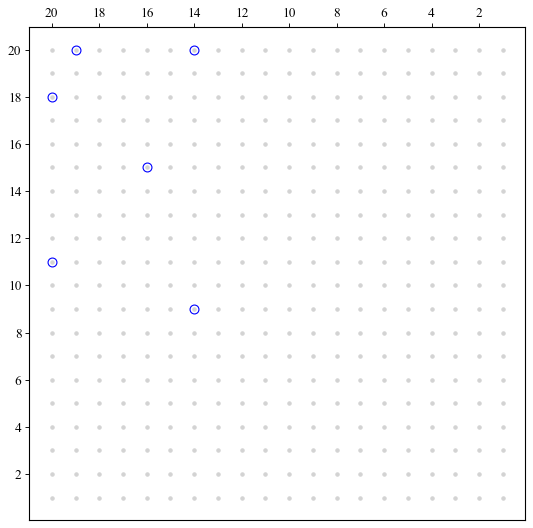

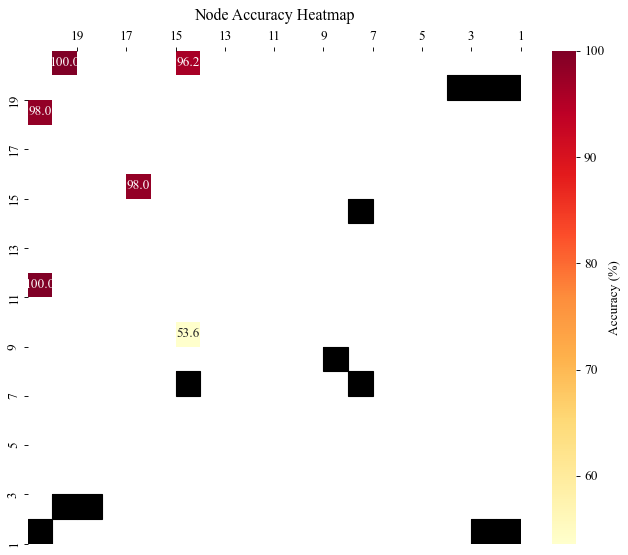

In [12]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from typing import List, Dict
import seaborn as sea

def get_per_class_accuracy(y_true, y_pred):
    # Convert to numpy arrays if they aren't already
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Get precision for each class (precision == accuracy for each class)
    precision, _, _, _ = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
    
    # Get unique labels
    labels = np.unique(y_true)
    
    # Create dictionary mapping labels to their accuracies
    accuracies = {str(label): round(prec * 100, 2) 
                 for label, prec in zip(labels, precision)}
    
    return accuracies

node_id_accuracies = get_per_class_accuracy(real, pred)
_, node_coordinates = utils.generate_grid_node_ids()
node_coord_accuracies = {}
for node_id in node_id_accuracies.keys():
    node_coord_str = node_coordinates[int(node_id)]
    node_coord_accuracies[node_coord_str] = node_id_accuracies[node_id]

grid_accuracies = np.zeros((20, 20))

plt.figure(figsize=(8, 8), dpi=80)
for i in np.arange(1, 21):
    for j in np.arange(1, 21):
        node = (i, j)

        plt.plot(i, j, '.', color='#D3D3D3')

        if (i, j) in node_coord_accuracies.keys():
            grid_accuracies[i-1, j-1] = node_coord_accuracies[(i, j)]
            plt.plot(i, j, 'o', markerfacecolor='none', markeredgecolor='blue', markersize=8)
        else: 
            grid_accuracies[i-1, j-1] = -1


# plt.plot(1, 1, 'o', color='black', markersize=10)
plt.xticks(np.arange(2, 21, 2))
plt.yticks(np.arange(2, 21, 2))
ax = plt.gca()
ax.invert_xaxis()
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.show()

wisig_tx_coordinates = [(1, 1),(1, 19),(14, 7),(18, 2),(19, 2),(2, 1),(2, 19),(20, 1),(3, 19),(7, 14),(7, 7),(8, 8)]
for x, y in wisig_tx_coordinates:
    grid_accuracies[x-1, y-1] = -100

# grid_accuracies[0, 0] = -100

##################

grid_accuracies = np.swapaxes(grid_accuracies, 0, 1)

from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from typing import List, Dict
import seaborn as sea
import numpy as np
import matplotlib.pyplot as plt

# Create two masks - one for -1 values (white) and one for -100 values (black)
mask_white = grid_accuracies == -1
mask_black = grid_accuracies == -100

# Create a copy of the data where we replace -100 with the maximum value
# (This ensures it gets the darkest color in our colormap)
grid_accuracies_modified = grid_accuracies.copy()
grid_accuracies_modified[mask_black] = np.nanmax(grid_accuracies[~mask_white & ~mask_black])

# Create custom annotation array
annot = np.zeros_like(grid_accuracies, dtype='object')
for i in range(grid_accuracies.shape[0]):
    for j in range(grid_accuracies.shape[1]):
        if grid_accuracies[i, j] != -1 and grid_accuracies[i, j] != -100:
            annot[i, j] = f'{grid_accuracies[i, j]:.1f}'
        else:
            annot[i, j] = ''

plt.figure(figsize=(10, 8), dpi=80)

# Create the base heatmap with white spaces for -1
ax = sea.heatmap(grid_accuracies_modified,
                 cmap='YlOrRd',
                 annot=annot,
                 fmt='',
                 cbar_kws={'label': 'Accuracy (%)'},
                 square=True,
                 xticklabels=np.arange(1, 21),
                 yticklabels=np.arange(1, 21),
                 mask=mask_white)  # Mask for white spaces

# Add black patches for -100 values
for i in range(grid_accuracies.shape[0]):
    for j in range(grid_accuracies.shape[1]):
        if grid_accuracies[i, j] == -100:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color='black'))

# Invert x-axis and y-axis
ax.invert_xaxis()
ax.invert_yaxis()

# Move x-axis to top
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

# Set the aspect ratio to be equal
ax.set_aspect('equal')

# Set tick frequency
plt.xticks(np.arange(0, 20, 2), np.arange(1, 21, 2))
plt.yticks(np.arange(0, 20, 2), np.arange(1, 21, 2))

plt.title('Node Accuracy Heatmap', pad=10)

plt.show()

In [9]:
import pickle

def load_compact_pkl_dataset(dataset_path,dataset_name):
    with open(dataset_path+dataset_name+'.pkl','rb') as f:
        dataset = pickle.load(f)
    return dataset

dataset = load_compact_pkl_dataset('/home/smazokha2016/Downloads/','ManySig')

dataset['rx_list']

['1-1',
 '1-19',
 '14-7',
 '18-2',
 '19-2',
 '2-1',
 '2-19',
 '20-1',
 '3-19',
 '7-14',
 '7-7',
 '8-8']

<!--  -->

### Little Experiment with CFO on WiSig

Let's evaluate what the CFO values look like for different devices across days (using raw non-equalized data). 

If there's major volatility -- maybe there's correlation between that volatility and devices that are often misclassified?..

In [16]:
# data, labels, rssi = dataset_api.load_raw_dataset('/home/smazokha2016/Desktop/wisig_dataset_new/node1-1_wifi_2021_03_01_e0:06:e6:18:45:cf.h5', shuffle=False)
data, labels, rssi = dataset_api.load_raw_dataset('/home/smazokha2016/Desktop/wisig_dataset_new/node1-1_wifi_2021_03_08.h5', shuffle=False)

In [17]:
print(set(labels.flatten()))
print(data.shape)

{1, 133, 398, 80, 114, 52, 152}
(7000, 400)


In [26]:
compare_a = set([9, 11, 15, 17, 25, 38, 52, 57, 60, 69, 80, 84, 129, 130, 133, 142, 147, 157, 190, 196, 203, 206, 239, 242, 280, 300, 315, 329, 330, 360, 378, 380, 391])
compare_b = set(labels.flatten())

for item in compare_a:
    if item not in compare_b: print(item)

In [ ]:
node_names = ['14-10', '14-7', '20-15', '20-19', '6-15', '8-20']
def generate_node_ids():
    ids = {}
    node_i = 0
    for i in np.arange(1, 21):
        for j in np.arange(1, 21):
            ids[str(i) + "-" + str(j)] = node_i
            node_i = node_i + 1
    return ids

node_ids_dict = generate_node_ids()
node_ids_present_set = set(labels.flatten())

for item in node_names:
    present = node_ids_dict[item] in node_ids_present_set
    print(f"{item}: {node_ids_dict[item]}: {present}")


14-10: 269: True
14-7: 266: True
20-15: 394: True
20-19: 398: True
6-15: 114: True
8-20: 159: True


Not removing CFO.
Not removing CFO.
Not removing CFO.
Not removing CFO.


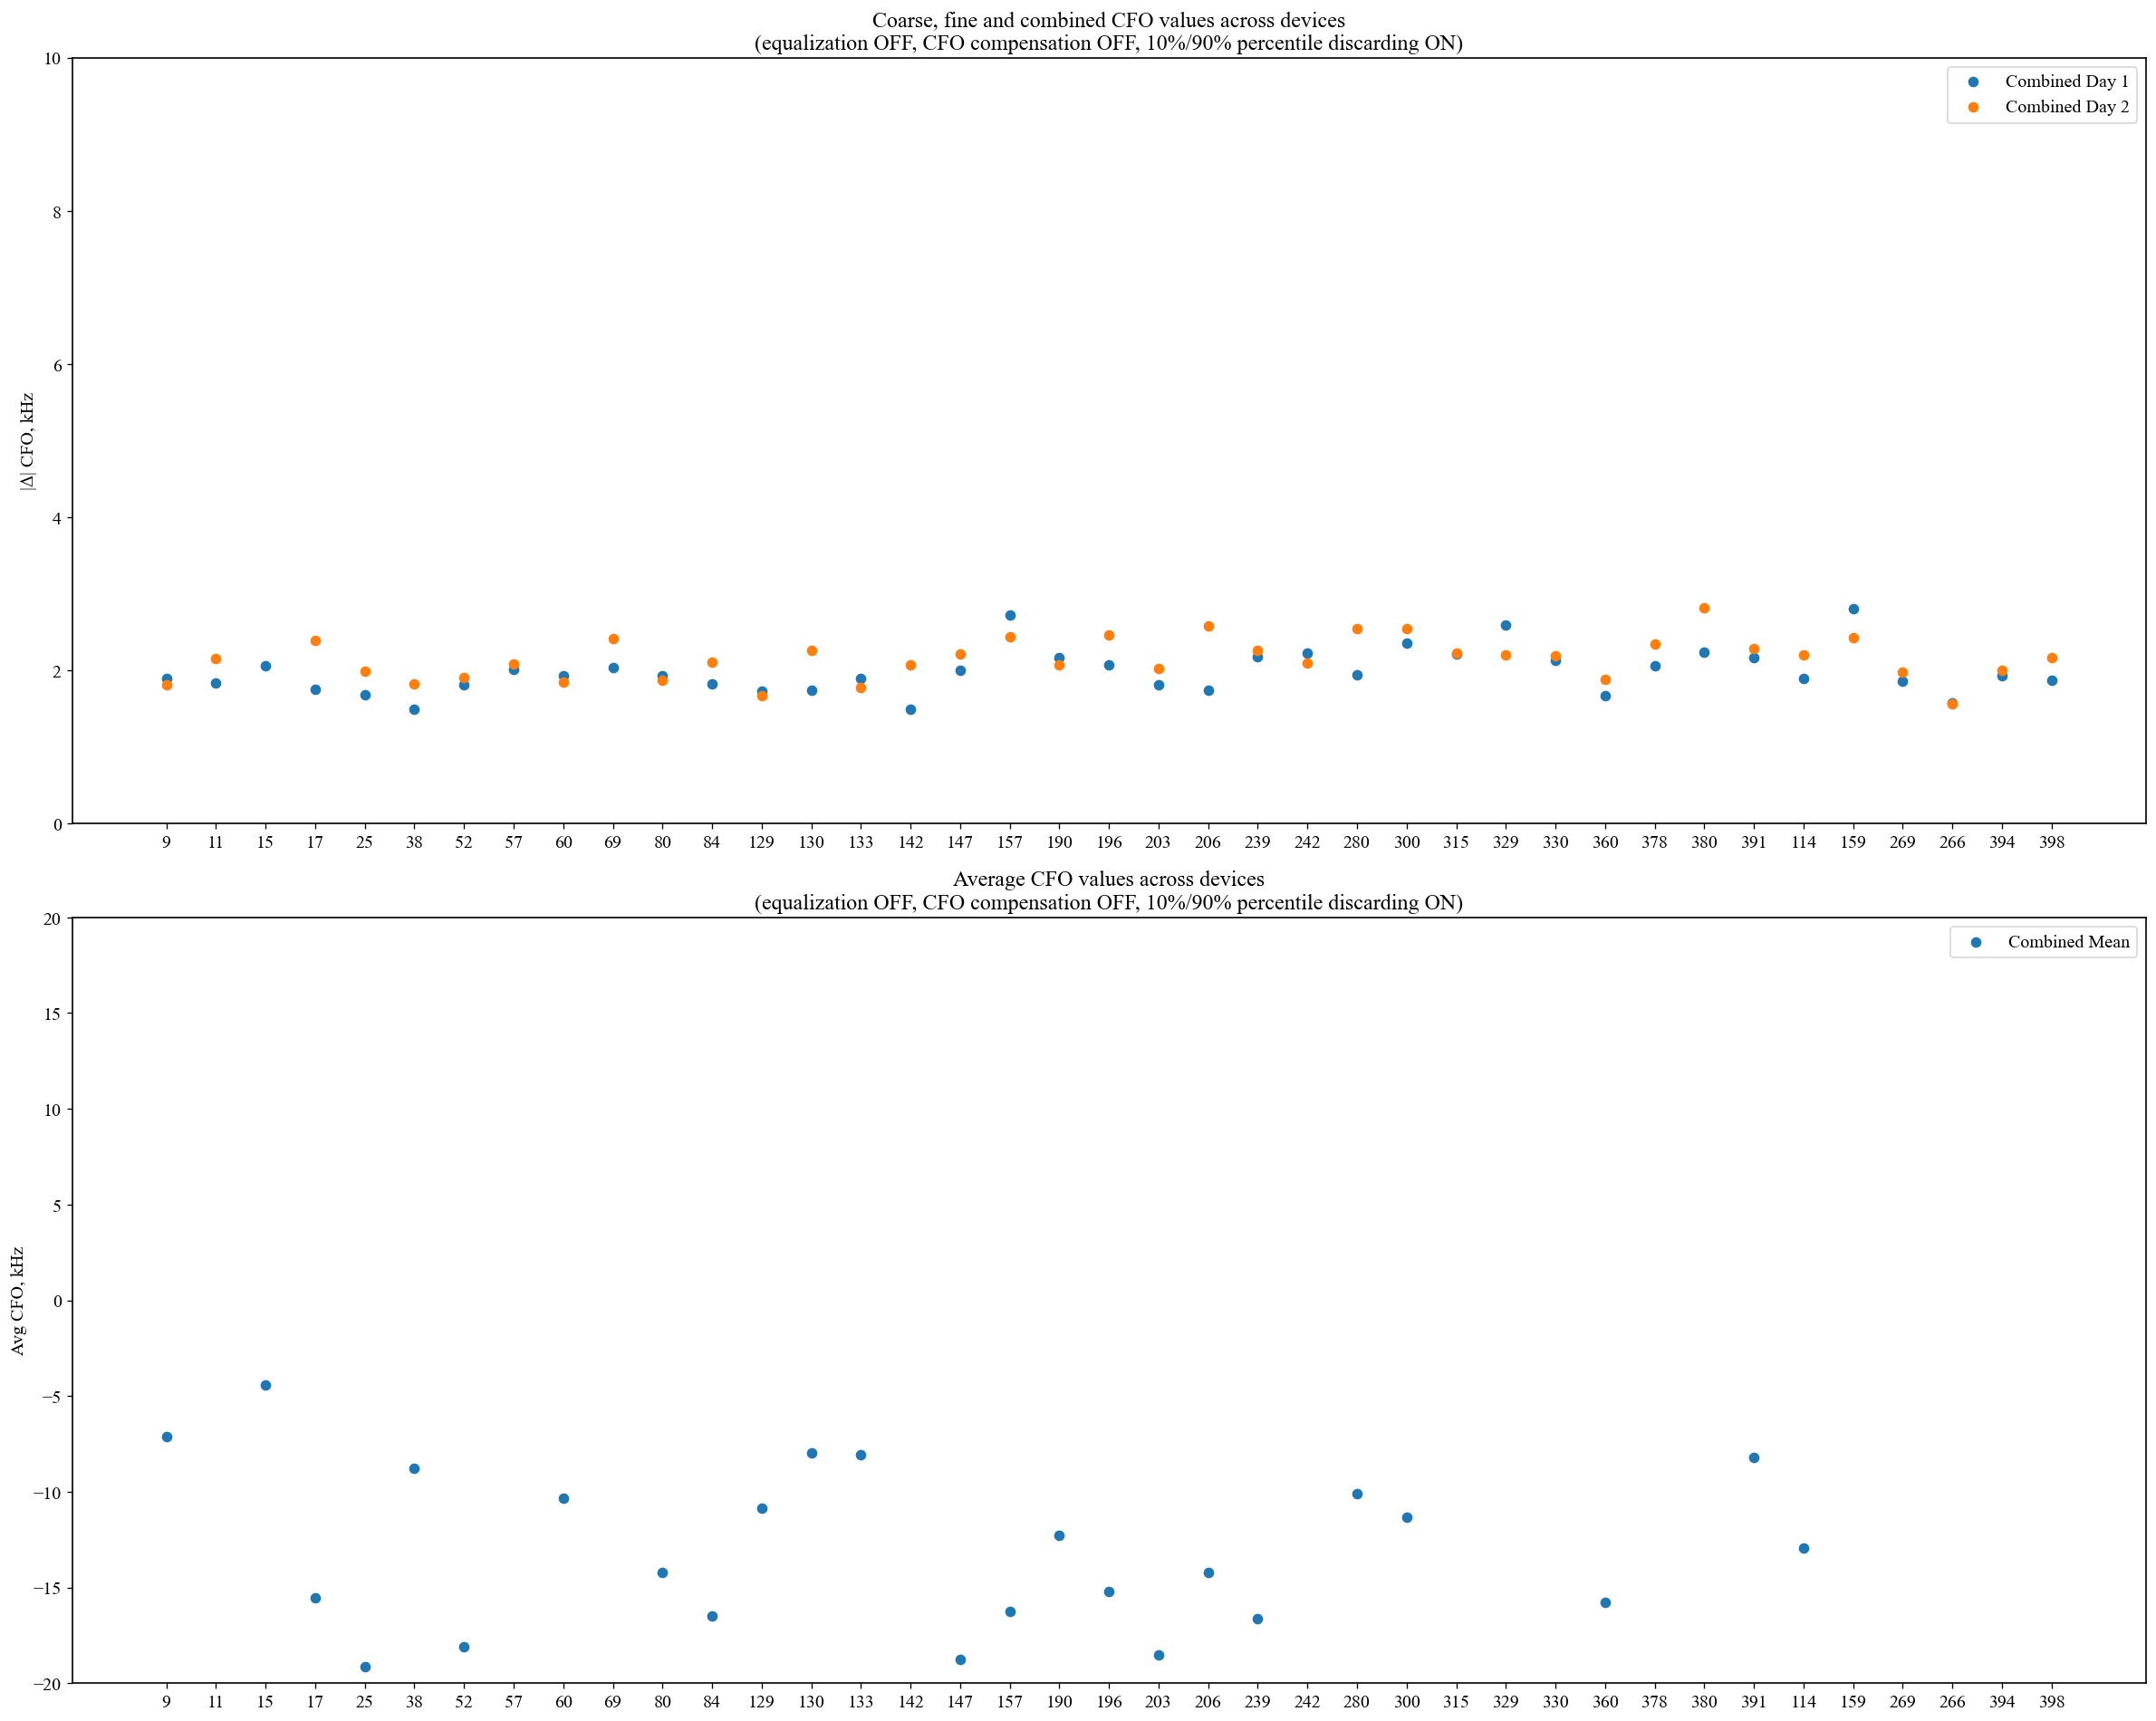

In [ ]:

equalization_on = False
cfo_compensation_on = False
cfo_frame_discarding_on = True

route_chunk = 'eq' if equalization_on else 'non_eq'

data_raw_11, label_raw_11, _ = dataset_api.load_raw_dataset_wisig(
    path=f'/home/smazokha2016/Desktop/wisig_dataset_old_1rx/wisig_dataset-2021_03_01/Train/node1-1_{route_chunk}_train.h5', 
    shuffle=False, compensate_cfo=cfo_compensation_on)
data_raw_12, label_raw_12, _ = dataset_api.load_raw_dataset_wisig(
    path=f'/home/smazokha2016/Desktop/wisig_dataset_old_1rx/wisig_dataset-2021_03_01/Test/{route_chunk}_epoch_2021-03-01_00-00-00.h5', 
    shuffle=False, compensate_cfo=cfo_compensation_on)
data_raw_21, label_raw_21, _ = dataset_api.load_raw_dataset_wisig(
    path=f'/home/smazokha2016/Desktop/wisig_dataset_old_1rx/wisig_dataset-2021_03_08/Train/node1-1_{route_chunk}_train.h5', 
    shuffle=False, compensate_cfo=cfo_compensation_on)
data_raw_22, label_raw_22, _ = dataset_api.load_raw_dataset_wisig(
    path=f'/home/smazokha2016/Desktop/wisig_dataset_old_1rx/wisig_dataset-2021_03_08/Test/{route_chunk}_epoch_2021-03-08_00-00-00.h5', 
    shuffle=False, compensate_cfo=cfo_compensation_on)

data_raw_1, label_raw_1 = combine_datasets(datas=[data_raw_11, data_raw_12], labels=[label_raw_11, label_raw_12])
data_raw_2, label_raw_2 = combine_datasets(datas=[data_raw_21, data_raw_22], labels=[label_raw_21, label_raw_22])

# Training devices
# Note: these are not all devices available in WiSig. This is a union between devices available on Day 1 and Day 2.
train_device_ids = [9, 11, 15, 17, 25, 38, 52, 57, 60, 69, 80, 84, 129, 130, 133, 142, 147, 157, 190, 196, 203, 206, 239, 242, 280, 300, 315, 329, 330, 360, 378, 380, 391]
# Testing devices: disjoint set
test_device_ids_disjoint = [114, 159, 269, 266, 394, 398]
# Testing devices: joint set (subset of training)
test_device_ids_joint = [9, 11, 15, 17, 25, 38]
# Combined joint and disjoint
combined_device_ids = train_device_ids + test_device_ids_disjoint

device_ids = combined_device_ids

coarse_day1_deltas = []
coarse_day2_deltas = []
coarse_means = []
fine_day1_deltas = []
fine_day2_deltas = []
fine_means = []
combined_day1_deltas = []
combined_day2_deltas = []
combined_means = []
combined_maxes = []
combined_mins = []

# plt.figure(figsize=(10, 8), dpi=80)
for device_id in device_ids:
    data_raw_1_dev, label_raw_1_dev, _ = dataset_api.filter_dataset(data_raw_1, label_raw_1, None, dev_range=[device_id], pkt_range=np.arange(0, 500))
    data_raw_2_dev, label_raw_2_dev, _ = dataset_api.filter_dataset(data_raw_2, label_raw_2, None, dev_range=[device_id], pkt_range=np.arange(0, 500))

    if cfo_frame_discarding_on:
        data_raw_1_dev, _, _ = dataset_api.filter_frames_by_cfo(data_raw_1_dev, label_raw_1_dev, None, show=False)
        data_raw_2_dev, _, _ = dataset_api.filter_frames_by_cfo(data_raw_2_dev, label_raw_2_dev, None, show=False)

    # Estimate coarse and fine CFO, and convert to kHz (divide by 1000)
    cfo_1 = cfo_utils.extract_data_cfo(data_raw_1_dev) / 1000
    cfo_2 = cfo_utils.extract_data_cfo(data_raw_2_dev) / 1000
    cfo_comb = np.vstack((cfo_1, cfo_2))
    
    # plt.plot(range(0, cfo_comb.shape[0]), cfo_comb[:, 0], label=f"Coarse. Device ID: {device_id}")
    # plt.plot(range(0, cfo_comb.shape[0]), cfo_comb[:, 1], label=f"Fine. Device ID: {device_id}")
    # plt.plot(range(0, cfo_comb.shape[0]), cfo_comb[:, 0] + cfo_comb[:, 1], label=f"Combined. Device ID: {device_id}")

    coarse_day1_min = min(cfo_1[:, 0])
    coarse_day1_max = max(cfo_1[:, 0])
    coarse_day1_delta = abs(coarse_day1_max - coarse_day1_min)
    coarse_day2_min = min(cfo_2[:, 0])
    coarse_day2_max = max(cfo_2[:, 0])
    coarse_day2_delta = abs(coarse_day2_max - coarse_day2_min)
    coarse_mean = np.mean(cfo_comb[:, 0])

    fine_day1_min = min(cfo_1[:, 1])
    fine_day1_max = max(cfo_1[:, 1])
    fine_day1_delta = abs(fine_day1_max - fine_day1_min)
    fine_day2_min = min(cfo_2[:, 1])
    fine_day2_max = max(cfo_2[:, 1])
    fine_day2_delta = abs(fine_day2_max - fine_day2_min)
    fine_mean = np.mean(cfo_comb[:, 1])

    combined_day1_min = min(cfo_1[:, 0] + cfo_1[:, 1])
    combined_day1_max = max(cfo_1[:, 0] + cfo_1[:, 1])
    combined_day1_delta = abs(combined_day1_max - combined_day1_min)
    combined_day2_min = min(cfo_2[:, 0] + cfo_2[:, 1])
    combined_day2_max = max(cfo_2[:, 0] + cfo_2[:, 1])
    combined_day2_delta = abs(combined_day2_max - combined_day2_min)
    combined_mean = np.mean(cfo_comb[:, 0] + cfo_comb[:, 1])

    coarse_day1_deltas.append(coarse_day1_delta)
    coarse_day2_deltas.append(coarse_day2_delta)
    coarse_means.append(coarse_mean)
    fine_day1_deltas.append(fine_day1_delta)
    fine_day2_deltas.append(fine_day2_delta)
    fine_means.append(fine_mean)
    combined_day1_deltas.append(combined_day1_delta)
    combined_day2_deltas.append(combined_day2_delta)
    combined_means.append(combined_mean)
    combined_maxes.append(max(combined_day1_max, combined_day2_max))
    combined_mins.append(min(combined_day1_min, combined_day2_min))
    
    # print(f'Device #{device_id}. Coarse CFO:')
    # print(f'- Day 1. min: {round(coarse_day1_min, 2)} kHz. max: {round(coarse_day1_max, 2)} kHz. Δ: {round(coarse_day1_delta, 2)} kHz')
    # print(f'- Day 2. min: {round(coarse_day2_min, 2)} kHz. max: {round(coarse_day2_max, 2)} kHz. Δ: {round(coarse_day2_delta, 2)} kHz')
    # print(f'Device #{device_id}. Fine CFO:')
    # print(f'- Day 1. min: {round(fine_day1_min, 2)} kHz. max: {round(fine_day1_max, 2)} kHz. Δ: {round(fine_day1_delta, 2)} kHz')
    # print(f'- Day 2. min: {round(fine_day2_min, 2)} kHz. max: {round(fine_day2_max, 2)} kHz. Δ: {round(fine_day2_delta, 2)} kHz')
    # print(f'Device #{device_id}. Combined CFO:')
    # print(f'- Day 1. min: {round(combined_day1_min, 2)} kHz. max: {round(combined_day1_max, 2)} kHz. Δ: {round(combined_day1_delta, 2)} kHz')
    # print(f'- Day 2. min: {round(combined_day2_min, 2)} kHz. max: {round(combined_day2_max, 2)} kHz. Δ: {round(combined_day2_delta, 2)} kHz')
    # print('===================================================================')

# plt.legend()
# plt.ylim(-20, 20)
# plt.xlabel('Sample Index. Day 1: 400-499. Day 2: 400-499.')
# plt.ylabel('Absolute CFO Values, kHz')
# plt.show()

device_count = len(device_ids)
title_equalization = "ON" if equalization_on else "OFF"
title_cfo_compensation = "ON" if cfo_compensation_on else "OFF"
title_cfo_filtering = "ON" if cfo_frame_discarding_on else "OFF"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 16), dpi=120)

# First subplot (deltas)
# ax1.scatter(range(device_count), coarse_day1_deltas, label='Coarse Day 1')
# ax1.scatter(range(device_count), coarse_day2_deltas, label='Coarse Day 2')
# ax1.scatter(range(device_count), fine_day1_deltas, label='Fine Day 1')
# ax1.scatter(range(device_count), fine_day2_deltas, label='Fine Day 2')
ax1.scatter(range(device_count), combined_day1_deltas, label='Combined Day 1')
ax1.scatter(range(device_count), combined_day2_deltas, label='Combined Day 2')
ax1.set_xticks(range(device_count))
ax1.set_xticklabels(device_ids)
ax1.legend()
ax1.set_ylabel('|Δ| CFO, kHz')
ax1.set_ylim(0, 10)
ax1.set_title(f'Coarse, fine and combined CFO values across devices\n(equalization {title_equalization}, CFO compensation {title_cfo_compensation}, 10%/90% percentile discarding {title_cfo_filtering})')

# Second subplot (means)
# ax2.scatter(range(device_count), coarse_means, label='Coarse Mean')
# ax2.scatter(range(device_count), fine_means, label='Fine Mean')
ax2.scatter(range(device_count), combined_means, label='Combined Mean')
ax2.set_xticks(range(device_count))
ax2.set_xticklabels(device_ids)
ax2.legend()
ax2.set_ylabel('Avg CFO, kHz')
ax2.set_ylim(-20, 20)
ax2.set_title(f'Average CFO values across devices\n(equalization {title_equalization}, CFO compensation {title_cfo_compensation}, 10%/90% percentile discarding {title_cfo_filtering})')

# Adjust the spacing between subplots
plt.tight_layout()
plt.show()